In [1]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated, Literal, List, TypedDict
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.output_parsers import PydanticOutputParser
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display
import asyncio


console = Console()

def show(response):
    console.print(
        Panel(
            # Pretty(response.model_dump()),
            Pretty(response),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

In [2]:
class graph_state(BaseModel):
    count: int

In [3]:
def increment(state: graph_state) -> graph_state:
    count = state.count
    print(count)
    new_count = count + 1
    print(new_count)
    state.count = new_count
    return state

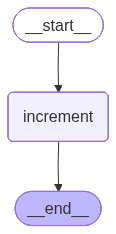

In [4]:
graph = StateGraph(graph_state)

graph.add_node('increment', increment)

graph.add_edge(START, 'increment')
graph.add_edge('increment', END)

checkpoint = InMemorySaver()

memory_graph = graph.compile(checkpointer = checkpoint)

Image(memory_graph.get_graph().draw_mermaid_png())

In [5]:
resp = memory_graph.invoke(graph_state(
    count = 0
),
{'configurable':{'thread_id': 'a'}})

0

1

In [6]:
resp = memory_graph.invoke(graph_state(
    count = 0
),
{'configurable':{'thread_id': 'b'}})

0

1

In [7]:
resp = memory_graph.invoke({},
{'configurable':{'thread_id': 'b'}})

1

2

In [8]:
history = memory_graph.get_state_history({'configurable':{'thread_id': 'b'}})
print(history)
for i, state in enumerate(history):
    print(i, state)

<generator object Pregel.get_state_history at 0x000001347E7DE6C0>

Deserializing unregistered type __main__.graph_state from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'graph_state')]


0
StateSnapshot(
    values={'count': 2},
    next=(),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c03a-6aca-8004-4d475b4b7376'
        }
    },
    metadata={'source': 'loop', 'step': 4, 'parents': {}},
    created_at='2026-03-22T10:53:01.850490+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02e-6f19-8003-e65775de9839'
        }
    },
    tasks=(),
    interrupts=()
)

1
StateSnapshot(
    values={'count': 1},
    next=('increment',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02e-6f19-8003-e65775de9839'
        }
    },
    metadata={'source': 'loop', 'step': 3, 'parents': {}},
    created_at='2026-03-22T10:53:01.845685+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02c-65e3-8002-318af0f8d1c2'
        }
    },
    tasks=(
        PregelTask(
            id='2628c39f-c672-2165-48f7-7fdbe8bc4f89',
            name='increment',
            path=('__pregel_pull', 'increment'),
            error=None,
            interrupts=(),
            state=None,
            result={'count': 2}
        ),
    ),
    interrupts=()
)

2
StateSnapshot(
    values={'count': 1},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02c-65e3-8002-318af0f8d1c2'
        }
    },
    metadata={'source': 'input', 'step': 2, 'parents': {}},
    created_at='2026-03-22T10:53:01.844630+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3fe-65de-8001-9f2077b8169e'
        }
    },
    tasks=(
        PregelTask(
            id='a217659f-6d3c-36e6-a8b6-6dff91d3f7c7',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={}
        ),
    ),
    interrupts=()
)

3
StateSnapshot(
    values={'count': 1},
    next=(),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3fe-65de-8001-9f2077b8169e'
        }
    },
    metadata={'source': 'loop', 'step': 1, 'parents': {}},
    created_at='2026-03-22T10:53:00.567497+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643b-8000-37a8c580142f'
        }
    },
    tasks=(),
    interrupts=()
)

4
StateSnapshot(
    values={'count': 0},
    next=('increment',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643b-8000-37a8c580142f'
        }
    },
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-03-22T10:53:00.562130+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643a-bfff-adc76e500a21'
        }
    },
    tasks=(
        PregelTask(
            id='c8aef24d-cbb4-23e3-79a4-5ca821388087',
            name='increment',
            path=('__pregel_pull', 'increment'),
            error=None,
            interrupts=(),
            state=None,
            result={'count': 1}
        ),
    ),
    interrupts=()
)

5
StateSnapshot(
    values={},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643a-bfff-adc76e500a21'
        }
    },
    metadata={'source': 'input', 'step': -1, 'parents': {}},
    created_at='2026-03-22T10:53:00.562130+00:00',
    parent_config=None,
    tasks=(
        PregelTask(
            id='cd521ddc-7860-eca3-8eea-063536a009dd',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={'count': 0}
        ),
    ),
    interrupts=()
)

In [13]:
config = {'configurable':{'thread_id': 'b'}}
history = list(memory_graph.get_state_history(config))
past_config = history[2].config
resp = memory_graph.invoke({},past_config)

Deserializing unregistered type __main__.graph_state from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'graph_state')]


1

2

In [14]:
history = list(memory_graph.get_state_history(config))
for i, state in enumerate(history):
    print(i, state)

Deserializing unregistered type __main__.graph_state from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'graph_state')]


0
StateSnapshot(
    values={'count': 2},
    next=(),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125df6-9eaa-6b51-8005-c509558e0bc2'
        }
    },
    metadata={'source': 'loop', 'step': 5, 'parents': {}},
    created_at='2026-03-22T11:08:11.011771+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125df6-9e9c-6f99-8004-abfdd4c07e2e'
        }
    },
    tasks=(),
    interrupts=()
)

1
StateSnapshot(
    values={'count': 1},
    next=('increment',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125df6-9e9c-6f99-8004-abfdd4c07e2e'
        }
    },
    metadata={'source': 'loop', 'step': 4, 'parents': {}},
    created_at='2026-03-22T11:08:11.006146+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125df6-9e99-6bf6-8003-b74d8be2825f'
        }
    },
    tasks=(
        PregelTask(
            id='7dbd2260-d58a-cf72-1a77-3dc2e9f1e764',
            name='increment',
            path=('__pregel_pull', 'increment'),
            error=None,
            interrupts=(),
            state=None,
            result={'count': 2}
        ),
    ),
    interrupts=()
)

2
StateSnapshot(
    values={'count': 1},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125df6-9e99-6bf6-8003-b74d8be2825f'
        }
    },
    metadata={'source': 'input', 'step': 3, 'parents': {}},
    created_at='2026-03-22T11:08:11.004824+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02c-65e3-8002-318af0f8d1c2'
        }
    },
    tasks=(
        PregelTask(
            id='c0c460bc-4809-66b5-3143-493ef674efa9',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={}
        ),
    ),
    interrupts=()
)

3
StateSnapshot(
    values={'count': 2},
    next=(),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c03a-6aca-8004-4d475b4b7376'
        }
    },
    metadata={'source': 'loop', 'step': 4, 'parents': {}},
    created_at='2026-03-22T10:53:01.850490+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02e-6f19-8003-e65775de9839'
        }
    },
    tasks=(),
    interrupts=()
)

4
StateSnapshot(
    values={'count': 1},
    next=('increment',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02e-6f19-8003-e65775de9839'
        }
    },
    metadata={'source': 'loop', 'step': 3, 'parents': {}},
    created_at='2026-03-22T10:53:01.845685+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02c-65e3-8002-318af0f8d1c2'
        }
    },
    tasks=(
        PregelTask(
            id='2628c39f-c672-2165-48f7-7fdbe8bc4f89',
            name='increment',
            path=('__pregel_pull', 'increment'),
            error=None,
            interrupts=(),
            state=None,
            result={'count': 2}
        ),
    ),
    interrupts=()
)

5
StateSnapshot(
    values={'count': 1},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-c02c-65e3-8002-318af0f8d1c2'
        }
    },
    metadata={'source': 'input', 'step': 2, 'parents': {}},
    created_at='2026-03-22T10:53:01.844630+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3fe-65de-8001-9f2077b8169e'
        }
    },
    tasks=(
        PregelTask(
            id='a217659f-6d3c-36e6-a8b6-6dff91d3f7c7',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={}
        ),
    ),
    interrupts=()
)

6
StateSnapshot(
    values={'count': 1},
    next=(),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3fe-65de-8001-9f2077b8169e'
        }
    },
    metadata={'source': 'loop', 'step': 1, 'parents': {}},
    created_at='2026-03-22T10:53:00.567497+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643b-8000-37a8c580142f'
        }
    },
    tasks=(),
    interrupts=()
)

7
StateSnapshot(
    values={'count': 0},
    next=('increment',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643b-8000-37a8c580142f'
        }
    },
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-03-22T10:53:00.562130+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643a-bfff-adc76e500a21'
        }
    },
    tasks=(
        PregelTask(
            id='c8aef24d-cbb4-23e3-79a4-5ca821388087',
            name='increment',
            path=('__pregel_pull', 'increment'),
            error=None,
            interrupts=(),
            state=None,
            result={'count': 1}
        ),
    ),
    interrupts=()
)

8
StateSnapshot(
    values={},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': 'b',
            'checkpoint_ns': '',
            'checkpoint_id': '1f125dd4-b3f1-643a-bfff-adc76e500a21'
        }
    },
    metadata={'source': 'input', 'step': -1, 'parents': {}},
    created_at='2026-03-22T10:53:00.562130+00:00',
    parent_config=None,
    tasks=(
        PregelTask(
            id='cd521ddc-7860-eca3-8eea-063536a009dd',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={'count': 0}
        ),
    ),
    interrupts=()
)